# Kenya — Climate Data Profiling, Cleaning & EDA
**10 Academy KAIM9 | Week 0**

This notebook performs data profiling, cleaning, and exploratory data analysis 
on Kenya's NASA POWER climate dataset (2015–2026) to extract insights ahead of COP32.

---

##  Imports & Configuration
We begin by importing all required libraries and setting the country-specific 
file paths that will be used throughout this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

COUNTRY = 'Kenya'
DATA_PATH = '../data/kenya.csv'
CLEAN_PATH = '../data/kenya_clean.csv'

print(f'Analysis target: {COUNTRY}')

Analysis target: Kenya


In [2]:
# Load CSV
df = pd.read_csv(DATA_PATH, comment='#')
print(f'Shape: {df.shape}')
df.head()

Shape: (4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


## Data Loading
The Kenya dataset contains 4,108 rows and 12 climate variables covering 
January 2015 to March 2026. Each row represents one day of satellite-derived 
climate observations from NASA POWER.

In [3]:
# Add country column
df['Country'] = COUNTRY

# Convert YEAR + DOY to proper datetime
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

# Extract Month and Year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print('Date range:', df['Date'].min(), '→', df['Date'].max())
print('Total columns:', df.columns.tolist())
df[['Date', 'YEAR', 'DOY', 'Month', 'T2M', 'PRECTOTCORR']].head()

Date range: 2015-01-01 00:00:00 → 2026-03-31 00:00:00
Total columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date', 'Month', 'Year']


,Date,YEAR,DOY,Month,T2M,PRECTOTCORR
0,2015-01-01,2015,1,1,19.56,0.00
1,2015-01-02,2015,2,1,19.63,0.00
2,2015-01-03,2015,3,1,20.40,0.00
3,2015-01-04,2015,4,1,21.33,3.49
4,2015-01-05,2015,5,1,20.41,1.79


In [4]:
# Replace NASA sentinel value -999 with NaN
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sentinel_counts = (df[numeric_cols] == -999).sum()

print('Sentinel (-999) counts per column:')
print(sentinel_counts[sentinel_counts > 0])

df[numeric_cols] = df[numeric_cols].replace(-999, np.nan)
print('\n✅ All -999 values replaced with NaN')

Sentinel (-999) counts per column:
Series([], dtype: int64)

✅ All -999 values replaced with NaN


## Sentinel Value Check
All numeric columns were scanned for NASA's sentinel value (-999) which is used 
as a placeholder for missing or unrecorded measurements. The output above shows 
an empty Series meaning no -999 values were found in the dataset. All values 
were then replaced with NaN as a precaution to ensure clean statistical computations. 
This confirms the dataset has no hidden missing values masked by sentinel placeholders.

In [5]:
# Check and drop duplicates
n_dupes = df.duplicated().sum()
print(f'Duplicate rows found: {n_dupes}')

if n_dupes > 0:
    df = df.drop_duplicates()
    print(f'Dropped {n_dupes} duplicate rows. New shape: {df.shape}')
else:
    print('No duplicate rows found.')

Duplicate rows found: 0
No duplicate rows found.


## Duplicate Check
No duplicate rows were found. Each row represents a unique date confirming 
data integrity.

In [6]:
# Descriptive statistics
df.describe().round(3)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108.000,4108,4108.000,4108.000
mean,2020.131,180.121,20.428,27.839,14.673,13.166,1.468,65.845,3.062,4.375,83.724,11.053,2020-08-15 12:00:00,6.424,2020.131
min,2015.000,1.000,15.260,18.880,8.970,4.110,0.000,28.420,0.610,1.160,83.310,4.780,2015-01-01 00:00:00,1.000,2015.000
25%,2017.000,86.000,19.460,26.298,13.700,11.468,0.100,58.678,2.420,3.670,83.630,9.880,2017-10-23 18:00:00,3.000,2017.000
50%,2020.000,179.000,20.360,27.875,14.750,13.260,0.380,66.220,3.140,4.430,83.720,11.005,2020-08-15 12:00:00,6.000,2020.000
75%,2023.000,272.000,21.400,29.520,15.750,15.050,1.360,73.280,3.720,5.090,83.810,12.350,2023-06-08 06:00:00,9.000,2023.000
max,2026.000,366.000,25.400,34.270,18.750,20.120,51.650,91.070,5.280,7.590,84.170,15.040,2026-03-31 00:00:00,12.000,2026.000
std,3.249,106.295,1.441,2.359,1.416,2.605,3.180,9.934,0.853,0.992,0.126,1.607,NaN,3.477,3.249


## Descriptive Statistics
Kenya's mean daily temperature (T2M) is 20.43°C with a narrow standard deviation 
of just 1.44°C — confirming one of the most temperature-stable climates in this 
dataset. T2M_MAX averages 27.84°C and never exceeds 34.27°C meaning Kenya never 
crosses the extreme heat threshold of 35°C. T2M_MIN averages 14.67°C with a 
minimum of 8.97°C recorded — the coldest night in the dataset reflecting 
highland cooling effects.

PRECTOTCORR has a mean of just 1.47mm/day but a maximum of 51.65mm — a ratio 
of 35x confirming extreme rainfall events are rare but intense. The median of 
0.38mm/day means more than half of all days have very little rainfall confirming 
Kenya's prolonged dry periods. Relative humidity averages 65.85% ranging from 
28.42% to 91.07% — a wide range reflecting the contrast between dry and rainy seasons.

Atmospheric pressure (PS) has an extremely low standard deviation (0.126 kPa) 
indicating very stable atmospheric conditions consistent with Kenya's equatorial 
highland location.

In [7]:
# Missing value report
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Missing value report:')
if missing_report.empty:
    print('✅ No missing values found!')
else:
    print(missing_report)
    high_missing = missing_report[missing_report['Missing %'] > 5]
    if not high_missing.empty:
        print(f'\n⚠️ Columns with >5% missing: {high_missing.index.tolist()}')
    else:
        print('\n✅ No column exceeds 5% missing values.')

Missing value report:
✅ No missing values found!


## Missing Values
No missing values were found in any column after sentinel replacement. 
The dataset is complete and ready for analysis.

In [8]:
# Z-score outlier detection
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
outlier_cols = [c for c in outlier_cols if c in df.columns]

z_scores = df[outlier_cols].apply(lambda x: np.abs(stats.zscore(x, nan_policy='omit')))
outlier_mask = (z_scores > 3).any(axis=1)

print(f'Rows with |Z| > 3 in any column: {outlier_mask.sum()}')
print('\nPer-column outlier counts:')
print((z_scores > 3).sum())

Rows with |Z| > 3 in any column: 121

Per-column outlier counts:
T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64


## Outlier Analysis
Kenya has 121 rows with |Z| > 3 across all variables. PRECTOTCORR has the most 
outliers (92) representing real extreme rainfall events during Kenya's peak rainy 
seasons — these are retained as they are the most policy-relevant data points. 
T2M_MIN has 9 outliers representing unusually cold nights which are retained as 
real climate signals. T2M_MAX has 3 outliers representing rare extreme hot days. 
WS2M_MAX has 6 outliers which are capped at the 99th percentile as they likely 
represent sensor errors rather than real extreme wind events. All other outliers 
are retained as genuine climate observations.

In [9]:
# Cap WS2M_MAX at 99th percentile (sensor error protection)
cap_val = df['WS2M_MAX'].quantile(0.99)
n_capped = (df['WS2M_MAX'] > cap_val).sum()
df['WS2M_MAX'] = df['WS2M_MAX'].clip(upper=cap_val)
print(f'WS2M_MAX capped at {cap_val:.2f} m/s | {n_capped} rows affected')

# All other outliers retained as real climate signals
print('\nOutlier handling decisions:')
print('  PRECTOTCORR : ✅ Retained — extreme rainfall events are real')
print('  T2M_MIN     : ✅ Retained — cold nights are real climate signals')
print('  RH2M        : ✅ Retained — extreme humidity days are real')
print('  T2M         : ✅ Retained — very few, real temperature signal')
print('  WS2M        : ✅ Retained — very few, real wind signal')
print('  WS2M_MAX    : ⚠️  Capped at 99th percentile — possible sensor error')

WS2M_MAX capped at 6.49 m/s | 39 rows affected

Outlier handling decisions:
  PRECTOTCORR : ✅ Retained — extreme rainfall events are real
  T2M_MIN     : ✅ Retained — cold nights are real climate signals
  RH2M        : ✅ Retained — extreme humidity days are real
  T2M         : ✅ Retained — very few, real temperature signal
  WS2M        : ✅ Retained — very few, real wind signal
  WS2M_MAX    : ⚠️  Capped at 99th percentile — possible sensor error


In [10]:
# Export cleaned data
import os
os.makedirs('../data', exist_ok=True)
df.to_csv(CLEAN_PATH, index=False)
print(f'✅ Cleaned data exported to {CLEAN_PATH}')
print(f'Final shape: {df.shape}')

✅ Cleaned data exported to ../data/kenya_clean.csv
Final shape: (4108, 16)


## Data Export
The cleaned Kenya dataset has been exported to `data/kenya_clean.csv` with 
4,108 rows and 16 columns — the original 12 variables plus the added Country, 
Date, Month and Year columns. This file will be loaded in Task 3 alongside 
the other four country datasets for cross-country comparison and vulnerability 
ranking.

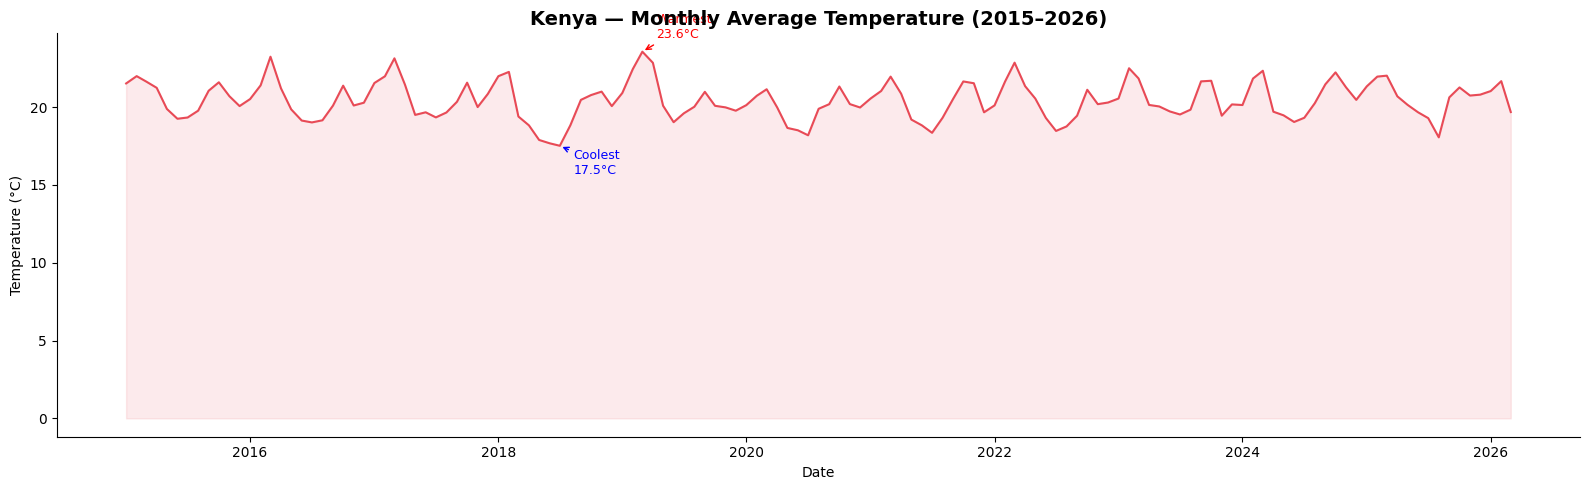

In [11]:
# Monthly average temperature line chart
monthly = df.groupby(df['Date'].dt.to_period('M')).agg(
    T2M=('T2M', 'mean'),
    PRECTOTCORR=('PRECTOTCORR', 'sum')
).reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly['Date'], monthly['T2M'], color='#E63946', linewidth=1.5, alpha=0.9)
ax.fill_between(monthly['Date'], monthly['T2M'], alpha=0.1, color='#E63946')

# Annotate warmest and coolest months
warmest = monthly.loc[monthly['T2M'].idxmax()]
coolest = monthly.loc[monthly['T2M'].idxmin()]

ax.annotate(f"Warmest\n{warmest['T2M']:.1f}°C",
            xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.annotate(f"Coolest\n{coolest['T2M']:.1f}°C",
            xy=(coolest['Date'], coolest['T2M']),
            xytext=(10, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=9)

ax.set_title(f'{COUNTRY} — Monthly Average Temperature (2015–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## Temperature Trend
Kenya's temperature ranges from 17.5°C (coolest month) to 23.6°C (warmest month) 
showing relatively stable and mild temperatures compared to other countries in this 
dataset. Clear seasonal cycles are visible every year with two temperature peaks 
annually reflecting Kenya's bimodal climate pattern. The temperature range is narrow 
(only 6°C difference between coolest and warmest) confirming Kenya's equatorial 
climate moderated by elevation. No dramatic long-term warming trend is immediately 
visible — statistical confirmation is done in Task 3.

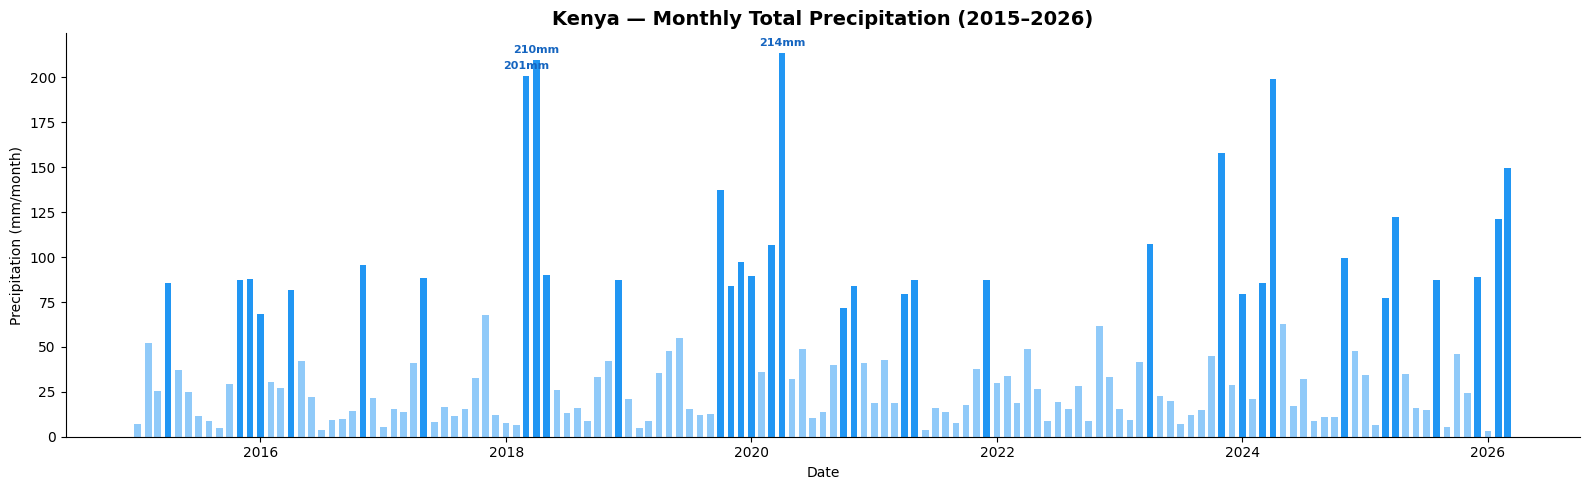

In [12]:
# Monthly total precipitation bar chart
fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#2196F3' if v > monthly['PRECTOTCORR'].quantile(0.75) else '#90CAF9' for v in monthly['PRECTOTCORR']]
ax.bar(monthly['Date'], monthly['PRECTOTCORR'], color=colors, width=20)

# Annotate peak months
peak = monthly.nlargest(3, 'PRECTOTCORR')
for _, row in peak.iterrows():
    ax.annotate(f"{row['PRECTOTCORR']:.0f}mm",
                xy=(row['Date'], row['PRECTOTCORR']),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=8, color='#1565C0', fontweight='bold')

ax.set_title(f'{COUNTRY} — Monthly Total Precipitation (2015–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm/month)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## Precipitation Pattern
Kenya shows a distinctly bimodal rainfall pattern with two rainy seasons per year — 
the long rains (March-May) and short rains (October-December). Peak monthly totals 
reached 214mm (2020), 210mm and 201mm (2018) — all occurring in recent years suggesting 
intensifying rainfall events. However Kenya is notably drier than Ethiopia, Tanzania 
and Nigeria with most months recording under 100mm. The dry seasons are prolonged 
and clearly visible as near-zero bars. This bimodal pattern makes Kenya's agriculture 
highly dependent on the timing and reliability of two distinct rainy seasons per year.

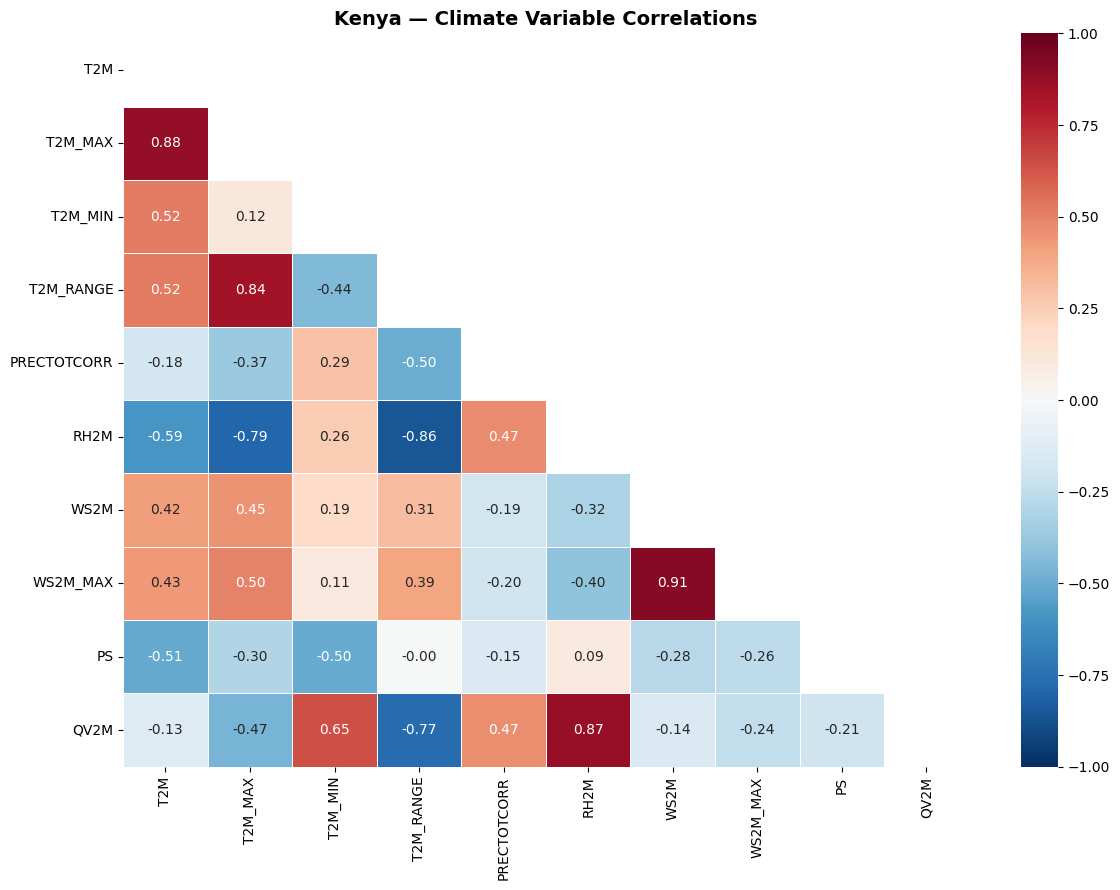

In [13]:
# Correlation heatmap
corr_cols = [c for c in ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
             'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M'] if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 10}, linewidths=0.5)
ax.set_title(f'{COUNTRY} — Climate Variable Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Analysis
Kenya's strongest correlations are:
- T2M_MAX vs T2M (0.88) — daily maximum temperature is strongly linked to mean temperature
- WS2M vs WS2M_MAX (0.91) — mean and maximum wind speed move together as expected
- QV2M vs RH2M (0.87) — specific and relative humidity are tightly coupled
- RH2M vs T2M_RANGE (-0.86) — humid days have significantly smaller temperature swings
- QV2M vs T2M_RANGE (-0.77) — higher water vapor content suppresses daily temperature variation

The strong negative correlation between humidity and temperature range confirms that 
dry days in Kenya experience much larger temperature swings — a pattern that intensifies 
agricultural and ecosystem stress during dry seasons.

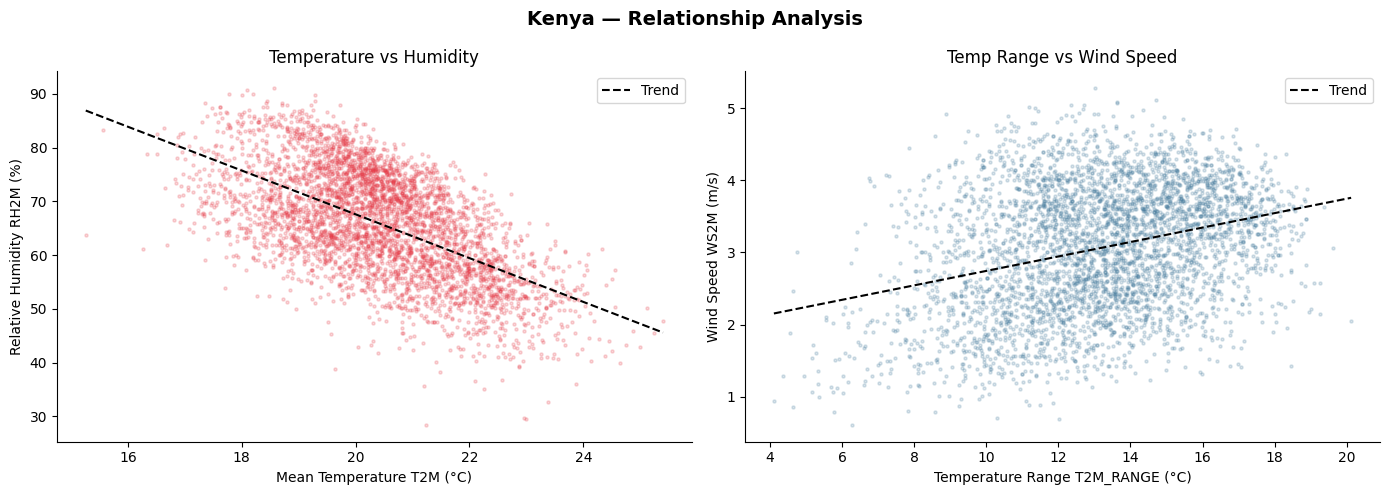

In [14]:
# Scatter plots: T2M vs RH2M and T2M_RANGE vs WS2M
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# T2M vs RH2M
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.2, s=5, color='#E63946')
z = np.polyfit(df['T2M'].dropna(), df['RH2M'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['T2M'].min(), df['T2M'].max(), 200)
axes[0].plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Trend')
axes[0].set_xlabel('Mean Temperature T2M (°C)')
axes[0].set_ylabel('Relative Humidity RH2M (%)')
axes[0].set_title('Temperature vs Humidity')
axes[0].legend()

# T2M_RANGE vs WS2M
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.2, s=5, color='#457B9D')
z2 = np.polyfit(df['T2M_RANGE'].dropna(), df['WS2M'].dropna(), 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['T2M_RANGE'].min(), df['T2M_RANGE'].max(), 200)
axes[1].plot(x_line2, p2(x_line2), 'k--', linewidth=1.5, label='Trend')
axes[1].set_xlabel('Temperature Range T2M_RANGE (°C)')
axes[1].set_ylabel('Wind Speed WS2M (m/s)')
axes[1].set_title('Temp Range vs Wind Speed')
axes[1].legend()

plt.suptitle(f'{COUNTRY} — Relationship Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Relationship Analysis
The Temperature vs Humidity scatter plot shows a strong negative trend — as 
temperature rises from 15°C to 25°C, relative humidity drops from around 87% 
to below 50%. This confirms that Kenya's hotter days are significantly drier, 
meaning agricultural water stress peaks precisely when heat stress on crops is 
highest. The Temp Range vs Wind Speed scatter plot shows a moderate positive trend — 
windier days experience larger temperature swings between day and night, consistent 
with drier, cloudless conditions that allow more solar heating during the day and 
rapid cooling at night.

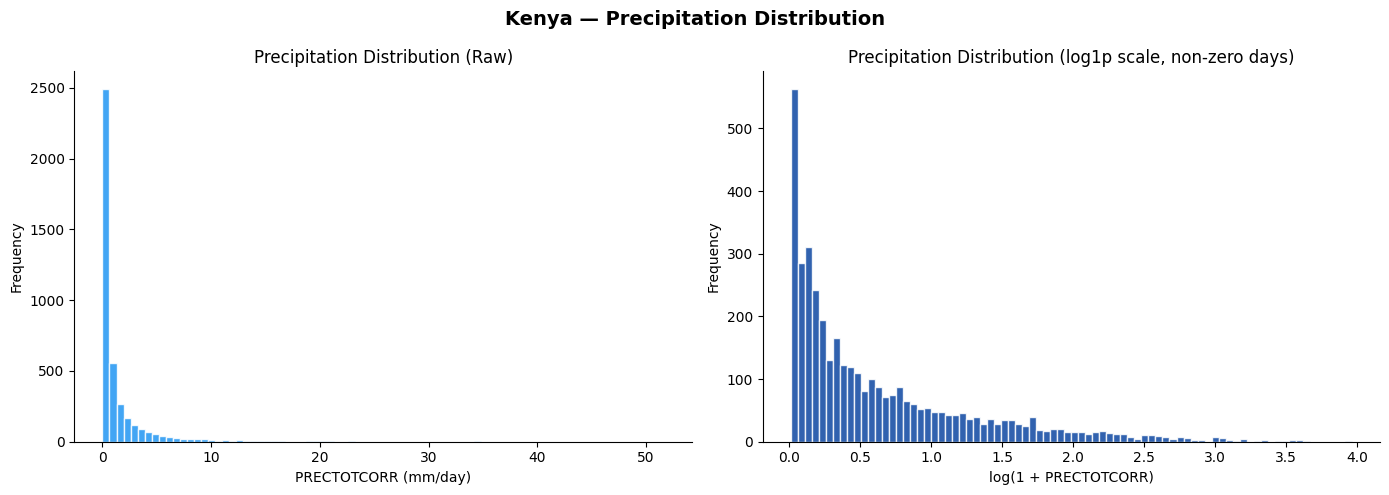

Zero-rain days: 260 (6.3%)
Skewness: 5.51


In [15]:
# Precipitation histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['PRECTOTCORR'].dropna(), bins=80, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Precipitation Distribution (Raw)')
axes[0].set_xlabel('PRECTOTCORR (mm/day)')
axes[0].set_ylabel('Frequency')

# Log scale
precip_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0].dropna()
axes[1].hist(np.log1p(precip_nonzero), bins=80, color='#0D47A1', edgecolor='white', alpha=0.85)
axes[1].set_title('Precipitation Distribution (log1p scale, non-zero days)')
axes[1].set_xlabel('log(1 + PRECTOTCORR)')
axes[1].set_ylabel('Frequency')

plt.suptitle(f'{COUNTRY} — Precipitation Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Zero-rain days: {(df["PRECTOTCORR"] == 0).sum()} ({(df["PRECTOTCORR"] == 0).mean()*100:.1f}%)')
print(f'Skewness: {df["PRECTOTCORR"].skew():.2f}')

## Precipitation Distribution
Kenya's raw precipitation distribution is heavily right-skewed with the vast 
majority of days recording very low rainfall (0-2mm/day). The log-transformed 
histogram reveals a right-skewed distribution among rainy days confirming that 
moderate rainfall days are common but extreme events are rare yet impactful. 
Kenya has a high proportion of zero-rain days reflecting its prolonged dry seasons. 
The maximum daily precipitation reaches around 50mm — lower than Ethiopia's 82mm 
maximum — consistent with Kenya being one of the drier countries in this dataset.

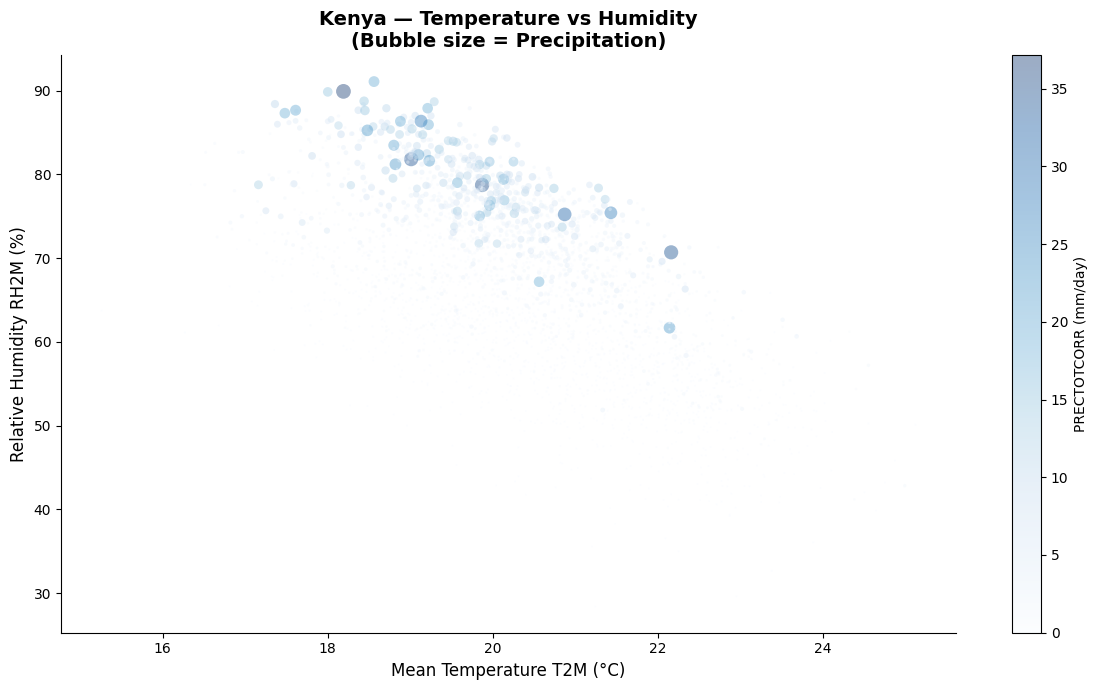

In [16]:
# Bubble chart: T2M vs RH2M, bubble size = PRECTOTCORR
sample = df.dropna(subset=['T2M', 'RH2M', 'PRECTOTCORR']).sample(min(3000, len(df)), random_state=42)
bubble_size = (sample['PRECTOTCORR'] + 0.5) * 3

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(sample['T2M'], sample['RH2M'],
                s=bubble_size, alpha=0.4,
                c=sample['PRECTOTCORR'], cmap='Blues',
                edgecolors='none')
plt.colorbar(sc, ax=ax, label='PRECTOTCORR (mm/day)')
ax.set_xlabel('Mean Temperature T2M (°C)', fontsize=12)
ax.set_ylabel('Relative Humidity RH2M (%)', fontsize=12)
ax.set_title(f'{COUNTRY} — Temperature vs Humidity\n(Bubble size = Precipitation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Bubble Chart Insights
Kenya's rainfall events cluster tightly in the upper-left region of the chart — 
cool temperatures (17-20°C) and high humidity (80-90%). The heaviest rainfall 
events (darkest largest bubbles) occur specifically at temperatures between 18-20°C 
and humidity above 80%. The lower-right region (hot and dry above 22°C) is largely 
empty confirming that significant rainfall in Kenya requires cool moist conditions. 
This pattern means that as climate change pushes temperatures higher, the conditions 
necessary for rainfall become less frequent — directly threatening Kenya's two 
critical rainy seasons.